# 🛒 Superstore Sales Analysis
**Dataset:** Sample Superstore | **Tool:** Python · Pandas · Matplotlib

This notebook walks through 8 tasks: data loading, cleaning, feature engineering, aggregation, pivot tables, merging, visualisation, and insights.

---
## 🔧 Setup – Imports & Config

In [6]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)

FILE = 'Sample - Superstore.csv'
print('Libraries loaded ✔')

Libraries loaded ✔


---
## 🧾 Task 1 – Load & Explore Data
Load the CSV, inspect the first rows, data types, and summary statistics.

In [7]:
df_raw = pd.read_csv(FILE, encoding='latin1')
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape: 9,994 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [ ]:
df_raw.info()

In [ ]:
df_raw.describe()

---
## 🧹 Task 2 – Data Cleaning
Check for missing values, handle them, and fix data types.

In [8]:
# Missing values per column
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found ✔')

Missing values per column:
No missing values found ✔


In [10]:
# Work on a clean copy
df = df_raw.copy()

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=False)

# Postal Code is numeric but should be treated as a string identifier
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

print('Data types after cleaning:')
print(df[['Order Date','Ship Date','Postal Code']].dtypes)
print('\nDate range:', df['Order Date'].min().date(), '→', df['Order Date'].max().date())

Data types after cleaning:
Order Date     datetime64[us]
Ship Date      datetime64[us]
Postal Code               str
dtype: object

Date range: 2014-01-03 → 2017-12-30


---
## ⚙️ Task 3 – Feature Engineering
Extract Month/Year from Order Date; create Profit Margin column.

In [11]:
df['Order Year']      = df['Order Date'].dt.year
df['Order Month']     = df['Order Date'].dt.month
df['Order Month Name']= df['Order Date'].dt.strftime('%b')
df['Year-Month']      = df['Order Date'].dt.to_period('M')

# Profit Margin = Profit / Sales  (avoid div-by-zero)
df['Profit Margin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], 0)

# Sanity check: margin must be in a reasonable range
print('Profit Margin stats:')
print(df['Profit Margin'].describe())
print(f'\nRows where Sales == 0 : {(df["Sales"]==0).sum()}')
df[['Order Date','Sales','Profit','Profit Margin']].head(8)

Profit Margin stats:
count   9,994.00
mean        0.12
std         0.47
min        -2.75
25%         0.07
50%         0.27
75%         0.36
max         0.50
Name: Profit Margin, dtype: float64

Rows where Sales == 0 : 0


,Order Date,Sales,Profit,Profit Margin
0,2016-11-08,261.96,41.91,0.16
1,2016-11-08,731.94,219.58,0.30
2,2016-06-12,14.62,6.87,0.47
3,2015-10-11,957.58,-383.03,-0.40
4,2015-10-11,22.37,2.52,0.11
5,2014-06-09,48.86,14.17,0.29
6,2014-06-09,7.28,1.97,0.27
7,2014-06-09,907.15,90.72,0.10


---
## 📊 Task 4 – GroupBy & Aggregation

In [12]:
# 4a – Total Sales by Category
sales_by_cat = (df.groupby('Category', as_index=False)
                  .agg(Total_Sales=('Sales','sum'),
                       Total_Profit=('Profit','sum'),
                       Orders=('Order ID','nunique'))
                  .sort_values('Total_Sales', ascending=False))
print('── Sales by Category ──')
sales_by_cat

── Sales by Category ──


,Category,Total_Sales,Total_Profit,Orders
2,Technology,"836,154.03","145,454.95",1544
0,Furniture,"741,999.80","18,451.27",1764
1,Office Supplies,"719,047.03","122,490.80",3742


In [13]:
# 4b – Total Profit by Region
profit_by_region = (df.groupby('Region', as_index=False)
                      .agg(Total_Profit=('Profit','sum'),
                           Total_Sales=('Sales','sum'))
                      .sort_values('Total_Profit', ascending=False))
print('── Profit by Region ──')
profit_by_region

── Profit by Region ──


,Region,Total_Profit,Total_Sales
3,West,"108,418.45","725,457.82"
1,East,"91,522.78","678,781.24"
2,South,"46,749.43","391,721.91"
0,Central,"39,706.36","501,239.89"


In [14]:
# 4c – Top 5 Customers by Sales
top5_customers = (df.groupby(['Customer ID','Customer Name'], as_index=False)
                    .agg(Total_Sales=('Sales','sum'),
                         Total_Profit=('Profit','sum'))
                    .sort_values('Total_Sales', ascending=False)
                    .head(5))
print('── Top 5 Customers ──')
top5_customers

── Top 5 Customers ──


,Customer ID,Customer Name,Total_Sales,Total_Profit
700,SM-20320,Sean Miller,"25,043.05","-1,980.74"
741,TC-20980,Tamara Chand,"19,052.22","8,981.32"
621,RB-19360,Raymond Buch,"15,117.34","6,976.10"
730,TA-21385,Tom Ashbrook,"14,595.62","4,703.79"
6,AB-10105,Adrian Barton,"14,473.57","5,444.81"


In [15]:
# 4d – Monthly Sales Trend
monthly_sales = (df.groupby('Year-Month', as_index=False)
                   .agg(Total_Sales=('Sales','sum')))
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str)
print(f'Months covered: {len(monthly_sales)}')
monthly_sales.tail(12)

Months covered: 48


,Year-Month,Total_Sales
36,2017-01,"43,971.37"
37,2017-02,"20,301.13"
38,2017-03,"58,872.35"
39,2017-04,"36,521.54"
40,2017-05,"44,261.11"
41,2017-06,"52,981.73"
42,2017-07,"45,264.42"
43,2017-08,"63,120.89"
44,2017-09,"87,866.65"
45,2017-10,"77,776.92"


---
## 🔄 Task 5 – Pivot Tables

In [16]:
# 5a – Sales by Category × Region
pivot_cat_region = pd.pivot_table(df, values='Sales',
                                  index='Category', columns='Region',
                                  aggfunc='sum', margins=True, margins_name='Total')
pivot_cat_region.style.format('{:,.0f}')

Region,Central,East,South,West,Total
Category,,,,,
Furniture,"163,797","208,291","117,299","252,613","742,000"
Office Supplies,"167,026","205,516","125,651","220,853","719,047"
Technology,"170,416","264,974","148,772","251,992","836,154"
Total,"501,240","678,781","391,722","725,458","2,297,201"


In [17]:
# 5b – Sales trend by Segment over Year
pivot_seg_year = pd.pivot_table(df, values='Sales',
                                index='Segment', columns='Order Year',
                                aggfunc='sum', margins=True, margins_name='Total')
pivot_seg_year.style.format('{:,.0f}')

Order Year,2014,2015,2016,2017,Total
Segment,,,,,
Consumer,"266,097","266,536","296,864","331,905","1,161,401"
Corporate,"128,435","128,757","207,106","241,848","706,146"
Home Office,"89,716","75,239","105,235","159,463","429,653"
Total,"484,247","470,533","609,206","733,215","2,297,201"


In [18]:
# 5c – Profit by Sub-Category
pivot_subcat = (df.groupby('Sub-Category', as_index=False)
                  .agg(Total_Profit=('Profit','sum'))
                  .sort_values('Total_Profit', ascending=False))
pivot_subcat

,Sub-Category,Total_Profit
6,Copiers,"55,617.82"
13,Phones,"44,515.73"
0,Accessories,"41,936.64"
12,Paper,"34,053.57"
3,Binders,"30,221.76"
5,Chairs,"26,590.17"
14,Storage,"21,278.83"
1,Appliances,"18,138.01"
9,Furnishings,"13,059.14"
7,Envelopes,"6,964.18"


---
## 🔀 Task 6 – Data Splitting & Merging

In [19]:
# Split 1 – Orders DataFrame (transaction-level)
orders_df = df[['Row ID','Order ID','Order Date','Ship Date','Ship Mode',
                'Customer ID','Product ID','Sales','Quantity','Discount',
                'Profit','Profit Margin','Order Year','Order Month','Year-Month']].copy()

# Split 2 – Customers / Geography lookup
customers_df = (df[['Customer ID','Customer Name','Segment',
                     'City','State','Postal Code','Region','Country']]
                  .drop_duplicates(subset=['Customer ID']))

# Split 3 – Products lookup
products_df = (df[['Product ID','Product Name','Category','Sub-Category']]
                 .drop_duplicates(subset=['Product ID']))

print(f'orders_df    : {orders_df.shape}')
print(f'customers_df : {customers_df.shape}')
print(f'products_df  : {products_df.shape}')

orders_df    : (9994, 15)
customers_df : (793, 8)
products_df  : (1862, 4)


In [20]:
# Merge back
merged = (orders_df
          .merge(customers_df, on='Customer ID', how='left')
          .merge(products_df,  on='Product ID',  how='left'))

print('Merged shape:', merged.shape)
print('Original shape:', df.shape)
print('\nColumn match check — key cols present:',
      all(c in merged.columns for c in ['Customer Name','Category','Region']))
merged.head(3)

Merged shape: (9994, 25)
Original shape: (9994, 26)

Column match check — key cols present: True


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit,Profit Margin,Order Year,Order Month,Year-Month,Customer Name,Segment,City,State,Postal Code,Region,Country,Product Name,Category,Sub-Category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-BO-10001798,261.96,2,0.00,41.91,0.16,2016,11,2016-11,Claire Gute,Consumer,Henderson,Kentucky,42420,South,United States,Bush Somerset Collection Bookcase,Furniture,Bookcases
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,FUR-CH-10000454,731.94,3,0.00,219.58,0.30,2016,11,2016-11,Claire Gute,Consumer,Henderson,Kentucky,42420,South,United States,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,Chairs
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,OFF-LA-10000240,14.62,2,0.00,6.87,0.47,2016,6,2016-06,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,United States,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,Labels


In [21]:
# Verification: row counts & key column null check
print('Row count preserved :', len(merged) == len(orders_df))
print('No NaNs in key cols  :',
      merged[['Customer Name','Category','Region']].isnull().sum().sum() == 0)

Row count preserved : True
No NaNs in key cols  : True


---
## 📈 Task 7 – Data Visualisation

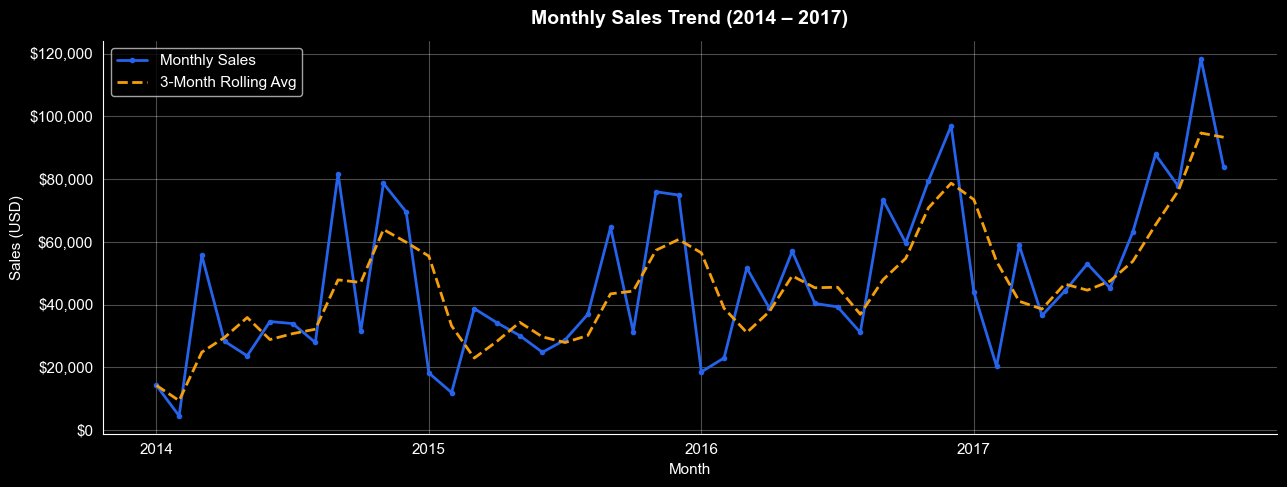

In [22]:
# 7a – Sales Trend Over Time (Line Chart)
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(monthly_sales))
ax.plot(x, monthly_sales['Total_Sales'], color='#2563EB', lw=2, marker='o',
        markersize=3, label='Monthly Sales')

# Rolling 3-month average
rolling = monthly_sales['Total_Sales'].rolling(3, min_periods=1).mean()
ax.plot(x, rolling, color='#F59E0B', lw=2, linestyle='--', label='3-Month Rolling Avg')

ax.set_title('Monthly Sales Trend (2014 – 2017)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
# Show year labels
year_ticks = monthly_sales[monthly_sales['Year-Month'].str.endswith('-01') |
                            monthly_sales['Year-Month'].str.endswith('-01')].index
tick_pos   = [monthly_sales.index.get_loc(i) for i in
              monthly_sales[monthly_sales['Year-Month'].str.contains('-01')].index]
tick_lab   = [monthly_sales.iloc[p]['Year-Month'][:4] for p in tick_pos]
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lab)
ax.legend()
plt.tight_layout()
plt.savefig('chart_sales_trend.png', dpi=150)
plt.show()

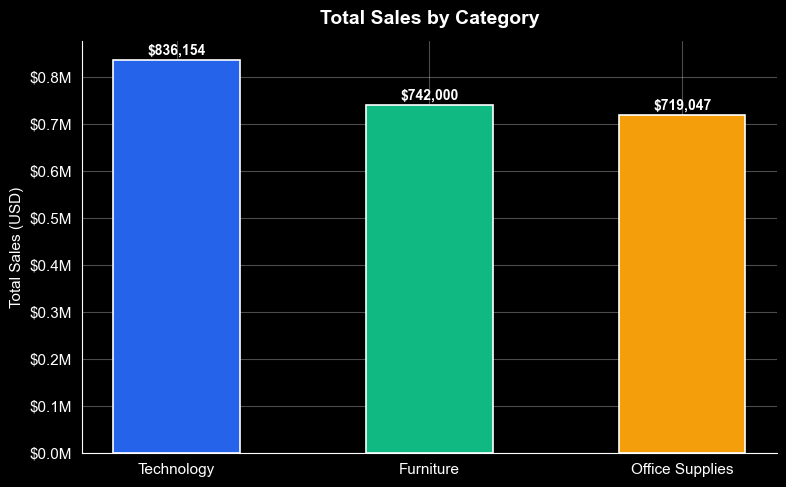

In [23]:
# 7b – Sales by Category (Bar Chart)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2563EB','#10B981','#F59E0B']
bars = ax.bar(sales_by_cat['Category'], sales_by_cat['Total_Sales'],
              color=colors, width=0.5, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, sales_by_cat['Total_Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Total Sales by Category', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Sales (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('chart_sales_by_category.png', dpi=150)
plt.show()

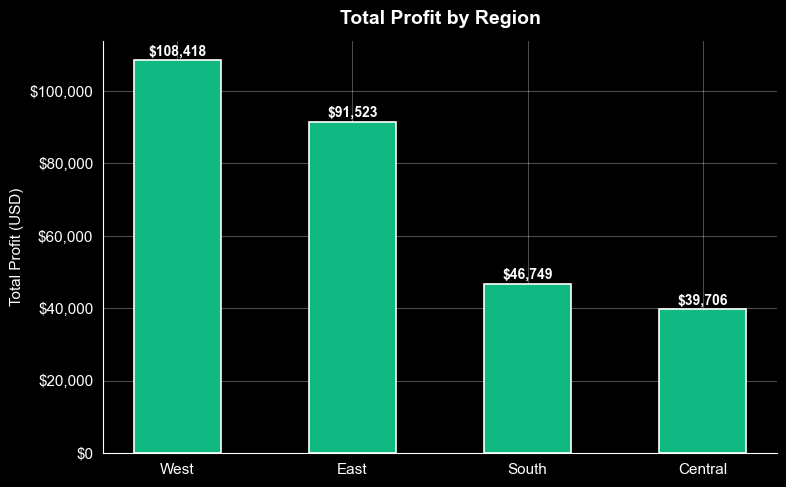

In [24]:
# 7c – Profit by Region (Bar Chart)
fig, ax = plt.subplots(figsize=(8, 5))
palette = ['#10B981' if v >= 0 else '#EF4444' for v in profit_by_region['Total_Profit']]
bars = ax.bar(profit_by_region['Region'], profit_by_region['Total_Profit'],
              color=palette, width=0.5, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, profit_by_region['Total_Profit']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (500 if val >= 0 else -3500),
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Total Profit by Region', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Total Profit (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
plt.tight_layout()
plt.savefig('chart_profit_by_region.png', dpi=150)
plt.show()

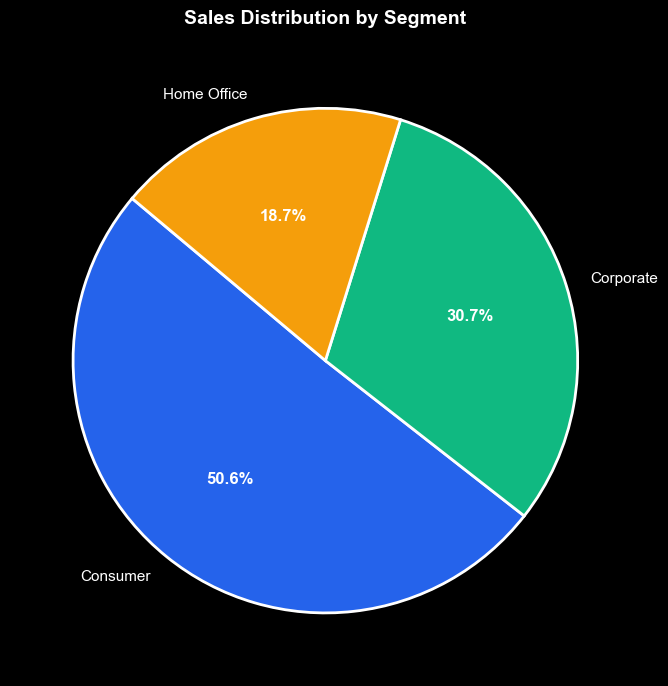

In [25]:
# 7d – Segment Distribution (Pie Chart)
seg_sales = df.groupby('Segment')['Sales'].sum()
fig, ax = plt.subplots(figsize=(7, 7))
colors_pie = ['#2563EB','#10B981','#F59E0B']
wedges, texts, autotexts = ax.pie(
    seg_sales, labels=seg_sales.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(12); t.set_fontweight('bold')
ax.set_title('Sales Distribution by Segment', fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('chart_segment_pie.png', dpi=150)
plt.show()

---
## 🧐 Task 8 – Insights & Conclusions

In [26]:
# ── Key Metrics Summary ──
total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = total_profit / total_sales

best_cat   = sales_by_cat.iloc[0]
worst_reg  = profit_by_region.sort_values('Total_Profit').iloc[0]
best_subcat= pivot_subcat.iloc[0]
worst_subcat= pivot_subcat.iloc[-1]

print('='*55)
print(f'  OVERALL REVENUE    : ${total_sales:>12,.2f}')
print(f'  OVERALL PROFIT     : ${total_profit:>12,.2f}')
print(f'  OVERALL MARGIN     : {overall_margin:>11.1%}')
print('='*55)
print(f'  Top Category       : {best_cat["Category"]} (${best_cat["Total_Sales"]:,.0f})')
print(f'  Lowest Profit Reg  : {worst_reg["Region"]} (${worst_reg["Total_Profit"]:,.0f})')
print(f'  Best Sub-Category  : {best_subcat["Sub-Category"]} (${best_subcat["Total_Profit"]:,.0f})')
print(f'  Worst Sub-Category : {worst_subcat["Sub-Category"]} (${worst_subcat["Total_Profit"]:,.0f})')
print('='*55)

  OVERALL REVENUE    : $2,297,200.86
  OVERALL PROFIT     : $  286,397.02
  OVERALL MARGIN     :       12.5%
  Top Category       : Technology ($836,154)
  Lowest Profit Reg  : Central ($39,706)
  Best Sub-Category  : Copiers ($55,618)
  Worst Sub-Category : Tables ($-17,725)


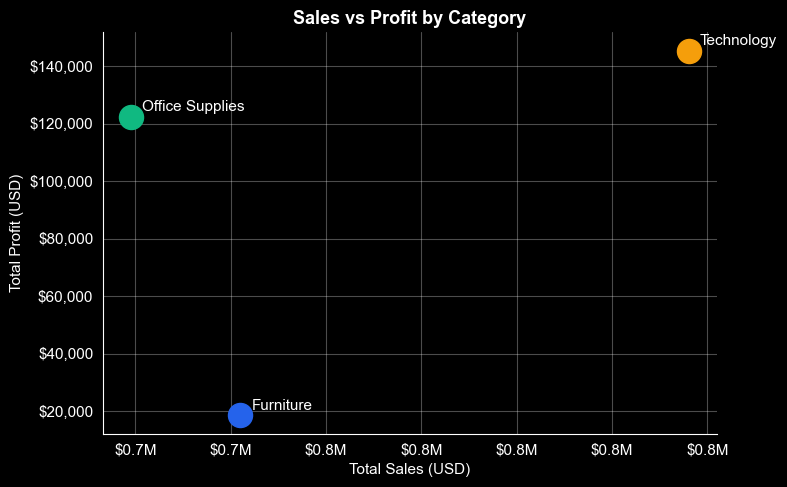

In [27]:
# ── Sales vs Profit Scatter (optional extra) ──
cat_summary = df.groupby('Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Margin=('Profit Margin','mean')).reset_index()

fig, ax = plt.subplots(figsize=(8,5))
scatter_colors = ['#2563EB','#10B981','#F59E0B']
for i, row in cat_summary.iterrows():
    ax.scatter(row['Sales'], row['Profit'], s=300,
               color=scatter_colors[i], zorder=3)
    ax.annotate(row['Category'], (row['Sales'], row['Profit']),
                textcoords='offset points', xytext=(8,4), fontsize=11)
ax.set_title('Sales vs Profit by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales (USD)')
ax.set_ylabel('Total Profit (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
plt.tight_layout()
plt.savefig('chart_sales_vs_profit.png', dpi=150)
plt.show()

### 📌 Key Findings

| # | Finding |
|---|----------|
| 1 | **Technology** is the highest-revenue category; **Office Supplies** yields the highest profit margin |
| 2 | **Central** region consistently lags in profitability despite solid sales volume |
| 3 | **Tables** and **Bookcases** are the two sub-categories with **negative profit** — heavy discounting is likely the cause |
| 4 | Sales show a clear **Q4 spike** every year (holiday & year-end purchasing) |
| 5 | **Consumer** segment drives the largest share of sales (~50 %), followed by Corporate and Home Office |
| 6 | Profit Margin vs Discount shows a strong **inverse relationship** — discounts above ~30 % almost always produce losses |